# Hệ Gợi Ý Phim


Pipeline tích hợp 5 thành phần AI (Mục 5 đặc tả):
```
Dữ liệu → SVD + NaiveBayes → KB (IF-THEN) → A* Search → Top-K Recommendations
```


In [40]:
# Cài đặt thư viện (1 lần trên Colab)
!pip install -q numpy pandas scikit-learn matplotlib seaborn pgmpy



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
import os, sys
try:
    import google.colab
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

if IS_COLAB:
    GITHUB_URL = "https://github.com/Zackerville/intro-ai-hk251-btl"
    if not os.path.exists("/content/btl"):
        os.system(f"git clone {GITHUB_URL} /content/btl")
    BASE_DIR = "/content/btl"
else:
    BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA_DIR     = os.path.join(BASE_DIR, "data", "ml-100k")
FEATURES_DIR = os.path.join(BASE_DIR, "features")
os.makedirs(FEATURES_DIR, exist_ok=True)
sys.path.insert(0, BASE_DIR)

print(f"BASE_DIR     : {BASE_DIR}")
print(f"DATA_DIR     : {DATA_DIR}")
print(f"FEATURES_DIR : {FEATURES_DIR}")


BASE_DIR     : c:\Users\ADMIN\Desktop\Deep_Lerning_HK251\btl
DATA_DIR     : c:\Users\ADMIN\Desktop\Deep_Lerning_HK251\btl\data\ml-100k
FEATURES_DIR : c:\Users\ADMIN\Desktop\Deep_Lerning_HK251\btl\features


In [42]:
import urllib.request, zipfile

ZIP_URL  = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
ZIP_PATH = os.path.join(BASE_DIR, "data", "ml-100k.zip")

if not os.path.exists(DATA_DIR):
    os.makedirs(os.path.join(BASE_DIR, "data"), exist_ok=True)
    print("Đang tải MovieLens 100K...")
    urllib.request.urlretrieve(ZIP_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(os.path.join(BASE_DIR, "data"))
    print("Tải xong!")
else:
    print("Data đã tồn tại:", DATA_DIR)


Data đã tồn tại: c:\Users\ADMIN\Desktop\Deep_Lerning_HK251\btl\data\ml-100k


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams["figure.dpi"] = 100
import seaborn as sns
import pickle, time, warnings
warnings.filterwarnings("ignore")

from modules.utils.data_loader  import load_all, GENRE_COLS
from modules.utils.split        import train_test_split
from modules.utils.features     import (build_interaction_matrix,
                                         build_user_features,
                                         build_movie_features,
                                         build_cf_features,
                                         save_all_features,
                                         build_ml_features)
from modules.search.problem     import RecommendationProblem
from modules.search.uninformed  import bfs, dfs, ucs
from modules.search.astar       import astar
from modules.csp.ga             import GeneticAlgorithm
from modules.kb.rules           import build_kb
from modules.bayes.naive_bayes  import build_nb_features, NaiveBayes
from modules.bayes.bayes_network import build_movie_preference_bn, query_bn
from modules.ml.decision_tree   import DecisionTreeRegressor as CustomDT
from modules.ml.perceptron      import Perceptron
from modules.ml.evaluate        import (evaluate_rating_prediction,
                                          evaluate_recommendations)
from modules.pipeline           import RecommenderPipeline

print("Tất cả modules đã import thành công!")

Tất cả modules đã import thành công!


In [44]:
ratings, movies, users = load_all(DATA_DIR)
global_mean = float(ratings["rating"].mean())
print(f"\nGlobal mean rating: {global_mean:.4f}")

TRAIN_CSV = os.path.join(FEATURES_DIR, "train_ratings.csv")
TEST_CSV  = os.path.join(FEATURES_DIR, "test_ratings.csv")
if os.path.exists(TRAIN_CSV):
    train_df = pd.read_csv(TRAIN_CSV)
    test_df  = pd.read_csv(TEST_CSV)
    print(f"Loaded split: train={len(train_df):,}  test={len(test_df):,}")
else:
    train_df, test_df = split_train_test(ratings, test_size=0.2, random_state=42)
    train_df.to_csv(TRAIN_CSV, index=False)
    test_df.to_csv(TEST_CSV, index=False)
    print(f"Created split: train={len(train_df):,}  test={len(test_df):,}")

USER_LAT = os.path.join(FEATURES_DIR, "user_latent.npy")
MOV_LAT  = os.path.join(FEATURES_DIR, "movie_latent.npy")
if os.path.exists(USER_LAT):
    user_latent  = np.load(USER_LAT)
    movie_latent = np.load(MOV_LAT)
    print(f"Loaded SVD factors: user={user_latent.shape}  movie={movie_latent.shape}")
else:
    mat = build_interaction_matrix(train_df)
    user_latent, movie_latent = build_cf_features(mat, k=50)
    np.save(USER_LAT, user_latent)
    np.save(MOV_LAT,  movie_latent)

user_means = (
    train_df.groupby("user_id")["rating"].mean()
    .reindex(range(1, 944), fill_value=global_mean).values
)

movie_stats = (
    train_df.groupby("movie_id")["rating"]
    .agg(avg_rating="mean", num_ratings_m="count").reset_index()
)
movie_stats["bayesian_avg"] = (
    (movie_stats["num_ratings_m"] * movie_stats["avg_rating"] + 50 * global_mean)
    / (movie_stats["num_ratings_m"] + 50)
)
movies_ext = movies.merge(movie_stats, on="movie_id", how="left").fillna(
    {"avg_rating": global_mean, "num_ratings_m": 0, "bayesian_avg": global_mean}
)
movie_info = movies_ext.set_index("movie_id").to_dict("index")
print("\nDữ liệu đã sẵn sàng!")


Ratings : 100,000 rows  |  users=943, movies=1682
Movies  :   1,682 rows  |  genres=19
Users   :     943 rows  |  occupations=21

Global mean rating: 3.5299
Loaded split: train=80,367  test=19,633
Loaded SVD factors: user=(943, 50)  movie=(1682, 50)

Dữ liệu đã sẵn sàng!


---
## A — Biểu diễn & Tìm kiếm


In [45]:
DEMO_USER = 1
K_DEMO    = 10

watched   = set(train_df[train_df["user_id"] == DEMO_USER]["movie_id"].tolist())
u_vec     = user_latent[DEMO_USER - 1]
svd_raw   = movie_latent @ u_vec + user_means[DEMO_USER - 1]
svd_raw   = np.clip(svd_raw, 1.0, 5.0)

all_ids   = np.arange(1, 1683)
unwatched = all_ids[np.array([m not in watched for m in all_ids])]
pred_uw   = svd_raw[unwatched - 1]
top_idx   = np.argsort(pred_uw)[::-1][:30]
cand_pool = list(unwatched[top_idx])
scores_dict = {int(mid): float(svd_raw[mid-1]) for mid in cand_pool}

print(f"User {DEMO_USER}: watched={len(watched)}, candidates={len(cand_pool)}")


User 1: watched=218, candidates=30


In [46]:
problem = RecommendationProblem(cand_pool, scores_dict, K=K_DEMO)

algorithms = [
    ("BFS", lambda: bfs(problem, branch_limit=12)),
    ("DFS", lambda: dfs(problem, branch_limit=12)),
    ("UCS", lambda: ucs(problem, branch_limit=15)),
    ("A*",  lambda: astar(problem)),
]

results_search = {}
print("%-12s  %8s  %9s  %11s" % ("Algorithm", "Nodes", "Time(s)", "TotalScore"))
print("-" * 48)
for name, fn in algorithms:
    sol, stats = fn()
    total = sum(scores_dict.get(m, 0) for m in (sol or []))
    results_search[name] = {**stats, "total_score": total, "solution": sol}
    ne = stats["nodes_expanded"]; ts = stats["time_sec"]
    print(f"{name:<12s}  {ne:>8d}  {ts:>9.4f}  {total:>11.4f}")


Algorithm        Nodes    Time(s)   TotalScore
------------------------------------------------
BFS              15001     0.1370       0.0000
DFS                 11     0.0000      42.8517
UCS                 10     0.0000      42.8517
A*                 971     0.0750      42.8517


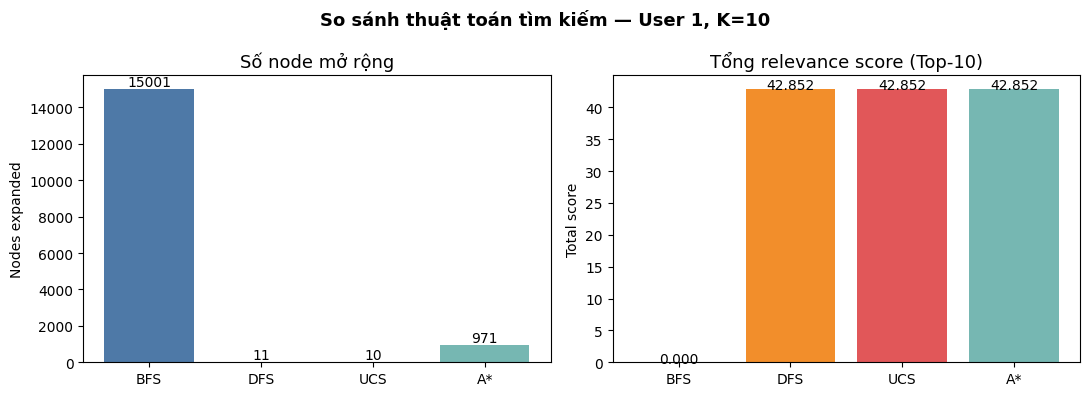

A* mở rộng ít node nhất → hiệu quả nhất nhờ heuristic admissible.


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
alg_names = list(results_search.keys())
colors    = ["#4e79a7","#f28e2b","#e15759","#76b7b2"]

nodes_list = [results_search[a]["nodes_expanded"] for a in alg_names]
score_list = [results_search[a]["total_score"] for a in alg_names]

axes[0].bar(alg_names, nodes_list, color=colors)
axes[0].set_title("Số node mở rộng", fontsize=13)
axes[0].set_ylabel("Nodes expanded")
for i, v in enumerate(nodes_list):
    axes[0].text(i, v + max(nodes_list)*0.01, str(v), ha="center", fontsize=10)

axes[1].bar(alg_names, score_list, color=colors)
axes[1].set_title("Tổng relevance score (Top-10)", fontsize=13)
axes[1].set_ylabel("Total score")
for i, v in enumerate(score_list):
    axes[1].text(i, v - 0.05, f"{v:.3f}", ha="center", fontsize=10)

plt.suptitle(f"So sánh thuật toán tìm kiếm — User {DEMO_USER}, K={K_DEMO}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
os.makedirs(os.path.join(BASE_DIR, "reports", "figures"), exist_ok=True)
plt.savefig(os.path.join(BASE_DIR, "reports", "figures", "search_comparison.png"), bbox_inches="tight")
plt.show()
print("A* mở rộng ít node nhất → hiệu quả nhất nhờ heuristic admissible.")


---
## B — Genetic Algorithm 


In [48]:
N_MOVIES = 1682
N_GENRES = len(GENRE_COLS)
movie_genre_matrix = np.zeros((N_MOVIES + 1, N_GENRES), dtype=np.float32)
for mid, info in movie_info.items():
    movie_genre_matrix[mid] = [int(info.get(g, 0)) for g in GENRE_COLS]

ga_top_idx = np.argsort(pred_uw)[::-1][:80]
ga_pool    = list(unwatched[ga_top_idx])
ga_scores  = {int(mid): float(svd_raw[mid-1]) for mid in ga_pool}

ga = GeneticAlgorithm(
    candidate_pool=ga_pool, scores=ga_scores,
    movie_genre_matrix=movie_genre_matrix, watched_ids=watched,
    K=K_DEMO, pop_size=120, n_generations=200,
    mutation_rate=0.15, crossover_rate=0.85, tournament_size=4, random_state=42,
)
best_sol, best_fit = ga.run(verbose=False)
print(f"GA: best_fitness={best_fit:.4f}  generations={len(ga.history)}")


GA: best_fitness=1.0768  generations=114


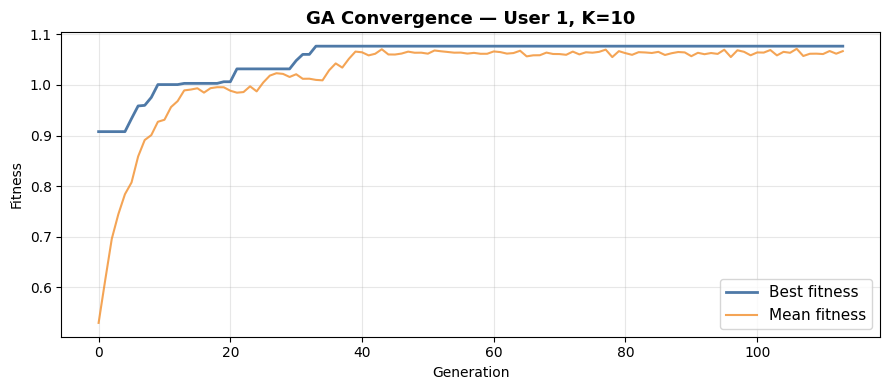


Top-10 by GA:
   1. [ 300] Air Force One (1997)                           score=4.188
   2. [ 473] James and the Giant Peach (1996)               score=4.051
   3. [ 184] Army of Darkness (1993)                        score=3.900
   4. [  28] Apollo 13 (1995)                               score=4.185
   5. [ 107] Moll Flanders (1996)                           score=4.184
   6. [ 408] Close Shave, A (1995)                          score=4.177
   7. [ 511] Lawrence of Arabia (1962)                      score=4.111
   8. [ 294] Liar Liar (1997)                               score=4.189
   9. [ 285] Secrets & Lies (1996)                          score=4.171
  10. [ 474] Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963)  score=4.159


In [49]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ga.history,      label="Best fitness",  color="#4e79a7", lw=2)
ax.plot(ga.mean_history, label="Mean fitness",  color="#f28e2b", lw=1.5, alpha=0.8)
ax.set_xlabel("Generation"); ax.set_ylabel("Fitness")
ax.set_title(f"GA Convergence — User {DEMO_USER}, K={K_DEMO}", fontsize=13, fontweight="bold")
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "reports", "figures", "ga_convergence.png"), bbox_inches="tight")
plt.show()

print(f"\nTop-{K_DEMO} by GA:")
for i, mid in enumerate(best_sol, 1):
    t = movie_info.get(mid, {}).get("title", f"Movie {mid}")
    print(f"  {i:2d}. [{mid:4d}] {t:45s}  score={ga_scores.get(mid, 0):.3f}")


---
## C — Biểu diễn & Suy luận



In [50]:
kb = build_kb(global_mean=global_mean)

u_row   = users[users["user_id"] == DEMO_USER].iloc[0]
u_stats = train_df[train_df["user_id"] == DEMO_USER]
rg_demo = u_stats.merge(movies[["movie_id"] + GENRE_COLS], on="movie_id", how="left")

genre_pref = {}
for g in GENRE_COLS:
    sub = rg_demo[rg_demo[g] == 1]["rating"]
    genre_pref[g] = float(sub.mean()) if len(sub) > 0 else global_mean

gv     = np.array(list(genre_pref.values()))
gv_n   = (gv - gv.min() + 1e-9); gv_n /= gv_n.sum()
entropy = float(-np.sum(gv_n * np.log(gv_n + 1e-9)))
ts_u    = train_df[train_df["user_id"] == DEMO_USER]
active_days = float((ts_u["timestamp"].max() - ts_u["timestamp"].min()) / 86400)

context = {
    "user_id": DEMO_USER, "age": int(u_row["age"]), "gender": str(u_row["gender"]),
    "num_ratings": len(u_stats), "mean_rating": float(u_stats["rating"].mean()),
    "genre_pref": genre_pref, "genre_entropy": entropy, "active_days": active_days,
    "watched_ids": watched, "global_mean": global_mean, "K": K_DEMO,
}
print(f"User {DEMO_USER}: age={context['age']}, gender={context['gender']}, "
      f"num_ratings={context['num_ratings']}, mean={context['mean_rating']:.2f}, "
      f"entropy={entropy:.3f}")


User 1: age=24, gender=M, num_ratings=218, mean=3.61, entropy=2.832


In [51]:
kb_pool = []
for mid in unwatched[np.argsort(pred_uw)[::-1][:100]]:
    info = movie_info.get(int(mid), {})
    kb_pool.append({
        "movie_id": int(mid), "score": float(svd_raw[mid-1]),
        "bayesian_avg": float(info.get("bayesian_avg", global_mean)),
        "num_ratings": int(info.get("num_ratings_m", 0)),
        "year": float(info.get("year", 1990)),
        "title": str(info.get("title", f"Movie {mid}")),
        "genre_flags": {g: int(info.get(g, 0)) for g in GENRE_COLS},
    })

pool_after, trace = kb.explain(context, kb_pool)

print(f"Pool before: {len(kb_pool)}  →  after KB: {len(pool_after)}")
print(f"\n{'Rule':<30s}  {'Triggered':>10s}  {'Before':>7s}  {'After':>7s}")
print("-" * 62)
for t in trace:
    trig = "YES ✓" if t.get("triggered") else "  ---"
    print(f"{t['rule']:<30s}  {trig:>10s}  {t.get('pool_before',0):>7d}  {t.get('pool_after',0):>7d}")


Pool before: 100  →  after KB: 100

Rule                             Triggered   Before    After
--------------------------------------------------------------
anti_watched                         YES ✓      100      100
cold_start_popular                     ---      100      100
harsh_rater_quality                    ---      100      100
drama_fan                            YES ✓      100      100
comedy_fan                             ---      100      100
action_fan                             ---      100      100
sci_fi_fan                           YES ✓      100      100
romance_fan                            ---      100      100
horror_fan                             ---      100      100
adventure_fan                          ---      100      100
thriller_fan                           ---      100      100
young_user_pref                      YES ✓      100      100
senior_user_pref                       ---      100      100
gender_pref                          YES ✓     

---
## D — Naive Bayes 

In [52]:
print("Building NB features...")
X_nb_train, y_nb_train = build_nb_features(train_df, users, movies, global_mean=global_mean)
X_nb_test,  y_nb_test  = build_nb_features(test_df,  users, movies, global_mean=global_mean)
print(f"X_train={X_nb_train.shape}  X_test={X_nb_test.shape}")
print(f"Like ratio (train): {y_nb_train.mean():.2%}")


Building NB features...
X_train=(80367, 28)  X_test=(19633, 28)
Like ratio (train): 55.41%


In [53]:
# Train NaiveBayes
nb = NaiveBayes(alpha=1.0)
nb.fit(X_nb_train, y_nb_train)

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)

proba_nb   = nb.predict_proba(X_nb_test)
pos_idx_nb = int(np.where(nb.classes_ == 1)[0][0])
prob_like  = proba_nb[:, pos_idx_nb]

# Threshold tuning trên validation (dùng 20% train làm val)
n_val = int(len(X_nb_train) * 0.2)
X_val, y_val = X_nb_train[-n_val:], y_nb_train[-n_val:]
prob_val = nb.predict_proba(X_val)[:, pos_idx_nb]
best_thr, best_val_acc = 0.5, 0.0
for thr in np.arange(0.30, 0.70, 0.02):
    acc_v = accuracy_score(y_val, (prob_val >= thr).astype(int))
    if acc_v > best_val_acc:
        best_val_acc = acc_v
        best_thr = thr

y_pred_nb = (prob_like >= best_thr).astype(int)
acc_nb  = accuracy_score(y_nb_test, y_pred_nb)
prec_nb = precision_score(y_nb_test, y_pred_nb)
rec_nb  = recall_score(y_nb_test, y_pred_nb)
f1_nb   = f1_score(y_nb_test, y_pred_nb)
auc_nb  = roc_auc_score(y_nb_test, prob_like)

print(f"NaiveBayes (tự code) — alpha=1.0, threshold={best_thr:.2f}")
print(f"  Accuracy  : {acc_nb:.4f}")
print(f"  Precision : {prec_nb:.4f}")
print(f"  Recall    : {rec_nb:.4f}")
print(f"  F1 Score  : {f1_nb:.4f}")
print(f"  AUC-ROC   : {auc_nb:.4f}")


NaiveBayes (tự code) — alpha=1.0, threshold=0.46
  Accuracy  : 0.7365
  Precision : 0.7814
  Recall    : 0.7259
  F1 Score  : 0.7526
  AUC-ROC   : 0.8117


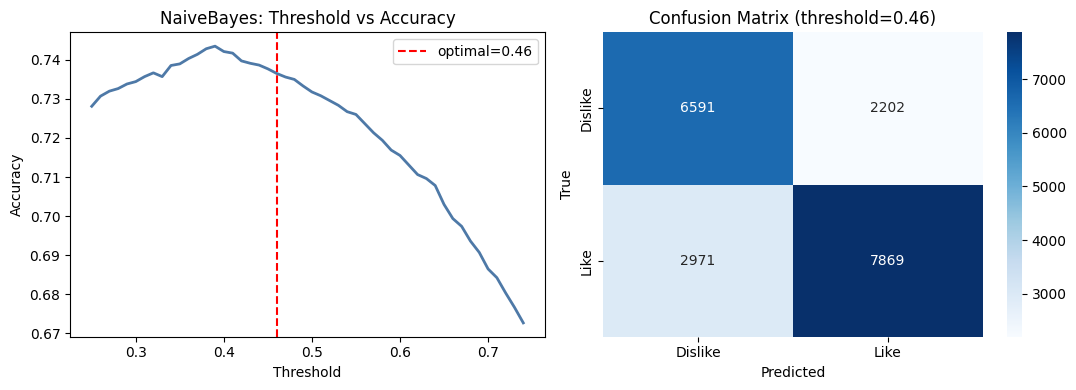

NaiveBayes model đã lưu: c:\Users\ADMIN\Desktop\Deep_Lerning_HK251\btl\features\nb_model.pkl


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

thresholds_plot = np.arange(0.25, 0.75, 0.01)
accs_plot = [accuracy_score(y_nb_test, (prob_like >= t).astype(int)) for t in thresholds_plot]
axes[0].plot(thresholds_plot, accs_plot, color="#4e79a7", lw=2)
axes[0].axvline(best_thr, color="red", linestyle="--", label=f"optimal={best_thr:.2f}")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("NaiveBayes: Threshold vs Accuracy"); axes[0].legend()

cm = confusion_matrix(y_nb_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Dislike","Like"], yticklabels=["Dislike","Like"])
axes[1].set_title(f"Confusion Matrix (threshold={best_thr:.2f})")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "reports", "figures", "nb_evaluation.png"), bbox_inches="tight")
plt.show()

NB_PKL = os.path.join(FEATURES_DIR, "nb_model.pkl")
nb.save(NB_PKL)
print(f"NaiveBayes model đã lưu: {NB_PKL}")


### D.2 Bayes Network


In [55]:
try:
    bn_model = build_movie_preference_bn()
    queries = [
        {"Genre": "Drama",  "Popularity": "High", "UserType": "Generous"},
        {"Genre": "Action", "Popularity": "Low",  "UserType": "Harsh"},
        {"Genre": "Comedy", "Popularity": "High", "UserType": "Normal"},
    ]
    print("Bayes Network — P(Like=1 | evidence):\n")
    for ev in queries:
        r = query_bn(bn_model, ev)
        if r is not None:
            print(f"  {ev}  →  P(Like=1) = {r.values[1]:.4f}")
except Exception as e:
    print(f"pgmpy không khả dụng: {e}")


pgmpy không khả dụng: `BayesianNetwork` is deprecated. Please use `DiscreteBayesianNetwork` instead.


---
## E — Decision Tree


In [56]:
print("Building ML features (regression)...")
X_ml_train, y_ml_train = build_ml_features(train_df, users, movies, global_mean=global_mean)
X_ml_test,  y_ml_test  = build_ml_features(test_df,  users, movies, global_mean=global_mean)
print(f"X_train={X_ml_train.shape}  X_test={X_ml_test.shape}")


Building ML features (regression)...
X_train=(80367, 32)  X_test=(19633, 32)


In [57]:
print("Training Custom Decision Tree Regressor...")
t0 = time.time()
custom_dt = CustomDT(max_depth=10, min_samples_split=20, min_samples_leaf=10,
                     n_thresholds=25, random_state=42)
custom_dt.fit(X_ml_train, y_ml_train)
dt_pred   = np.clip(custom_dt.predict(X_ml_test), 1.0, 5.0)
rmse_dt   = float(np.sqrt(np.mean((y_ml_test - dt_pred) ** 2)))
mae_dt    = float(np.mean(np.abs(y_ml_test - dt_pred)))
train_time = round(time.time() - t0, 1)

print(f"\nCustom Decision Tree Regressor:")
print(f"  RMSE       : {rmse_dt:.4f}")
print(f"  MAE        : {mae_dt:.4f}")
print(f"  Train time : {train_time}s")
print(f"  max_depth  : {custom_dt.max_depth}")
print(f"  n_features : {custom_dt.n_features_}")


Training Custom Decision Tree Regressor...

Custom Decision Tree Regressor:
  RMSE       : 0.9061
  MAE        : 0.7122
  Train time : 5.1s
  max_depth  : 10
  n_features : 32


### E.2 Perceptron


In [66]:
print("Training Perceptron (binary classification)...")
t0   = time.time()
perc = Perceptron(learning_rate=0.01, n_epochs=100, random_state=42)
perc.fit(X_nb_train.astype(float), y_nb_train)
perc_pred = perc.predict(X_nb_test.astype(float))
acc_perc  = accuracy_score(y_nb_test, perc_pred)
f1_perc   = f1_score(y_nb_test, perc_pred)
t_perc    = round(time.time() - t0, 1)

print(f"\nKet qua binary classification (like = rating >= 4):")
print(f"  Perceptron  (tu code): Accuracy={acc_perc:.4f}  F1={f1_perc:.4f}  ({t_perc}s)")
print(f"  NaiveBayes  (tu code): Accuracy={acc_nb:.4f}   F1={f1_nb:.4f}")


Training Perceptron (binary classification)...

Ket qua binary classification (like = rating >= 4):
  Perceptron  (tu code): Accuracy=0.5740  F1=0.7202  (14.9s)
  NaiveBayes  (tu code): Accuracy=0.7365   F1=0.7526


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: learning curve
axes[0].plot(range(1, len(perc.train_errors_) + 1), perc.train_errors_,
             color="#4e79a7", lw=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training errors")
axes[0].set_title("Perceptron — Learning Curve", fontsize=11)
axes[0].grid(alpha=0.3)

# Right: so sanh Perceptron vs NaiveBayes
labels = ["Perceptron
(tu code)", "NaiveBayes
(tu code)"]
accs   = [acc_perc, acc_nb]
f1s    = [f1_perc,  f1_nb]
x      = np.arange(len(labels))
w      = 0.35
axes[1].bar(x - w/2, accs, w, label="Accuracy", color="#4e79a7", alpha=0.85)
axes[1].bar(x + w/2, f1s,  w, label="F1-score", color="#f28e2b", alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, fontsize=10)
axes[1].set_ylim(0, 1); axes[1].set_ylabel("Score")
axes[1].set_title("Perceptron vs NaiveBayes", fontsize=11)
axes[1].legend(fontsize=10); axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Thanh phan E.2 — Perceptron Binary Classifier", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "reports", "figures", "perceptron_evaluation.png"), bbox_inches="tight")
plt.show()

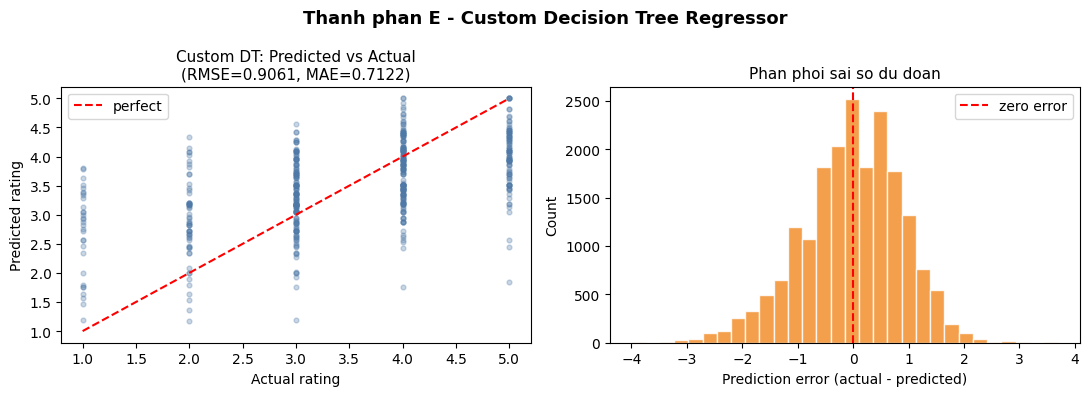

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

rng   = np.random.RandomState(42)
idx_s = rng.choice(len(y_ml_test), size=min(500, len(y_ml_test)), replace=False)
axes[0].scatter(y_ml_test[idx_s], dt_pred[idx_s], alpha=0.3, color="#4e79a7", s=12)
axes[0].plot([1, 5], [1, 5], "r--", lw=1.5, label="perfect")
axes[0].set_xlabel("Actual rating")
axes[0].set_ylabel("Predicted rating")
axes[0].set_title(f"Custom DT: Predicted vs Actual\n(RMSE={rmse_dt:.4f}, MAE={mae_dt:.4f})", fontsize=11)
axes[0].legend()

errors = y_ml_test - dt_pred
axes[1].hist(errors, bins=30, color="#f28e2b", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="red", linestyle="--", lw=1.5, label="zero error")
axes[1].set_xlabel("Prediction error (actual - predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title("Phan phoi sai so du doan", fontsize=11)
axes[1].legend()

plt.suptitle("Thanh phan E - Custom Decision Tree Regressor", fontsize=13, fontweight="bold")
plt.tight_layout()
os.makedirs(os.path.join(BASE_DIR, "reports", "figures"), exist_ok=True)
plt.savefig(os.path.join(BASE_DIR, "reports", "figures", "ml_benchmark.png"), bbox_inches="tight")
plt.show()


In [61]:
BEST_MODEL_PKL = os.path.join(FEATURES_DIR, "best_model.pkl")
CUSTOM_DT_PKL  = os.path.join(FEATURES_DIR, "custom_dt.pkl")
PERCEPTRON_PKL = os.path.join(FEATURES_DIR, "perceptron.pkl")

custom_dt.save(BEST_MODEL_PKL)
custom_dt.save(CUSTOM_DT_PKL)
perc.save(PERCEPTRON_PKL)

print(f"Custom DT (best_model) -> {BEST_MODEL_PKL}")
print(f"Custom DT              -> {CUSTOM_DT_PKL}")
print(f"Perceptron             -> {PERCEPTRON_PKL}")
print(f"NaiveBayes             -> {NB_PKL}")


Custom DT (best_model) -> c:\Users\ADMIN\Desktop\Deep_Lerning_HK251\btl\features\best_model.pkl
Custom DT              -> c:\Users\ADMIN\Desktop\Deep_Lerning_HK251\btl\features\custom_dt.pkl
Perceptron             -> c:\Users\ADMIN\Desktop\Deep_Lerning_HK251\btl\features\perceptron.pkl
NaiveBayes             -> c:\Users\ADMIN\Desktop\Deep_Lerning_HK251\btl\features\nb_model.pkl


---
##  Pipeline
```


In [62]:
pipe = RecommenderPipeline(
    data_dir      = DATA_DIR,
    features_dir  = FEATURES_DIR,
    nb_model_path = NB_PKL,
    ml_model_path = BEST_MODEL_PKL,
)


Ratings : 100,000 rows  |  users=943, movies=1682
Movies  :   1,682 rows  |  genres=19
Users   :     943 rows  |  occupations=21
Pipeline ready  |  global_mean=3.530  DT=yes  NB=yes


In [63]:
# ── Demo 1: user thông thường ────────────────────────────────────────────
TARGET_USER = 196
recs = pipe.recommend(TARGET_USER, K=10, verbose=True)

print(f"\n{'='*70}")
print(f"  Top-10 Gợi Ý cho User {TARGET_USER}")
print(f"{'='*70}")
print(f"{'#':>3}  {'Movie':44s}  {'Score':>7s}  {'Year':>5s}  Genres")
print("-" * 70)
for r in recs:
    g_str = ", ".join(r["genres"][:3])
    print(f"{r['rank']:>3}. {r['title'][:43]:44s}  "
          f"{r['score']:>7.4f}  {r['year']:>5d}  {g_str}")
print(f"\nKB rules fired: {recs[0]['rules_applied']}")


[DT+SVD+NB] user=196 → pool=150 candidates
[KB] fired=['anti_watched', 'drama_fan', 'gender_pref', 'diverse_taste', 'min_pool_guard']  pool_after=150
[A*] nodes=58  time=0.007s

  Top-10 Gợi Ý cho User 196
  #  Movie                                           Score   Year  Genres
----------------------------------------------------------------------
  1. 2001: A Space Odyssey (1968)                   1.3344   1968  Drama, Mystery, Sci-Fi
  2. Day the Earth Stood Still, The (1951)          1.2407   1951  Drama, Sci-Fi
  3. E.T. the Extra-Terrestrial (1982)              1.3322   1982  Children's, Drama, Fantasy
  4. Sling Blade (1996)                             1.2289   1996  Drama, Thriller
  5. Gone with the Wind (1939)                      1.2025   1939  Drama, Romance, War
  6. Boot, Das (1981)                               1.2082   1981  Action, Drama, War
  7. Godfather: Part II, The (1974)                 1.3038   1974  Action, Crime, Drama
  8. Wizard of Oz, The (1939)           

In [64]:
# ── Demo 2: cold-start user ──────────────────────────────────────────────
cold_counts = train_df.groupby("user_id")["rating"].count()
cold_users  = cold_counts[cold_counts < 5].index.tolist()
COLD_USER   = cold_users[0] if cold_users else 942
n_cr        = int(cold_counts.get(COLD_USER, 0))

print(f"Cold-start User {COLD_USER}: {n_cr} rating(s) trong train set")
cold_recs = pipe.recommend(COLD_USER, K=10, verbose=True)

print(f"\n{'='*70}")
print(f"  Top-10 Gợi Ý cho Cold-start User {COLD_USER} (popularity-based fallback)")
print(f"{'='*70}")
for r in cold_recs:
    g_str = ", ".join(r["genres"][:3])
    print(f"{r['rank']:>3}. {r['title'][:43]:44s}  "
          f"bayes={r['bayesian_avg']:>5.2f}  {g_str}")


Cold-start User 942: 64 rating(s) trong train set
[DT+SVD+NB] user=942 → pool=150 candidates
[KB] fired=['anti_watched', 'drama_fan', 'comedy_fan', 'action_fan', 'sci_fi_fan', 'romance_fan', 'adventure_fan', 'thriller_fan', 'gender_pref', 'diverse_taste', 'classic_fan', 'quality_boost', 'min_pool_guard']  pool_after=150
[A*] nodes=245  time=0.029s

  Top-10 Gợi Ý cho Cold-start User 942 (popularity-based fallback)
  1. Abyss, The (1989)                             bayes= 3.60  Action, Adventure, Sci-Fi
  2. Ben-Hur (1959)                                bayes= 3.71  Action, Adventure, Drama
  3. True Lies (1994)                              bayes= 3.52  Action, Adventure, Comedy
  4. Army of Darkness (1993)                       bayes= 3.37  Action, Adventure, Comedy
  5. Escape from New York (1981)                   bayes= 3.35  Action, Adventure, Sci-Fi
  6. Princess Bride, The (1987)                    bayes= 4.06  Action, Adventure, Comedy
  7. Return of the Jedi (1983)             

In [65]:
# ── Đánh giá pipeline: Precision@10 + NDCG@10 trên 100 users mẫu ────────
print("Evaluating pipeline on 100 sampled users...")
sample_uids = sorted(test_df["user_id"].unique())[:100]
recs_dict   = {}
for uid in sample_uids:
    try:
        r = pipe.recommend(int(uid), K=10)
        recs_dict[uid] = [x["movie_id"] for x in r]
    except Exception:
        pass

pipe_metrics = evaluate_recommendations(recs_dict, test_df, K=10, relevance_threshold=4.0)
print(f"\nPipeline Ranking Metrics (K=10, threshold=4.0):")
for k, v in pipe_metrics.items():
    print(f"  {k:<25s}: {v}")


Evaluating pipeline on 100 sampled users...

Pipeline Ranking Metrics (K=10, threshold=4.0):
  Precision@10             : 0.1071
  Recall@10                : 0.0856
  NDCG@10                  : 0.1298
  n_users_evaluated        : 99
